# 📅 Notebook 3: Sliding-Window Counter

The simplest limiter is a **fixed-window counter**: "max 5 requests per
calendar second". But that has a nasty flaw — a client can send 5 at
`0:59.99` and 5 more at `1:00.01`, for **10 req in 20ms**. Same window,
different clock, but real traffic doesn't respect wall clocks.

**Sliding-window log** fixes this by tracking *actual timestamps* of recent
requests. Used in production by Cloudflare, GitHub, Stripe.


## 🛠️ Setup

```bash
cd 04-patterns/rate-limiting-and-throttling
uv sync
```

Select the `.venv` kernel in VS Code (top-right of the notebook). If it doesn't appear, reload the window: `Cmd+Shift+P` → **Reload Window**.


## ❌ Bad: fixed-window counter — the boundary burst

In [1]:
import time
from collections import deque

class FixedWindow:
    def __init__(self, limit, window):
        self.limit = limit; self.window = window
        self.start = time.monotonic(); self.count = 0
    def allow(self):
        now = time.monotonic()
        if now - self.start >= self.window:
            self.start = now; self.count = 0
        if self.count < self.limit:
            self.count += 1; return True
        return False

fw = FixedWindow(limit=5, window=1.0)
print('end-of-window burst:', [int(fw.allow()) for _ in range(5)])
fw.start -= 1.0   # pretend the window just rolled (simulates t crossing boundary)
print('start-of-next-window:', [int(fw.allow()) for _ in range(5)])
print('-> 10 requests allowed in effectively zero time: 2× the intended rate!')

end-of-window burst: [1, 1, 1, 1, 1]
start-of-next-window: [1, 1, 1, 1, 1]
-> 10 requests allowed in effectively zero time: 2× the intended rate!


## ✅ Better: sliding-window log — exact everywhere

In [2]:
class SlidingWindow:
    def __init__(self, limit, window):
        self.limit = limit; self.window = window
        self.events = deque()
    def allow(self):
        now = time.monotonic()
        cutoff = now - self.window
        # drop events older than the window
        while self.events and self.events[0] < cutoff:
            self.events.popleft()
        if len(self.events) < self.limit:
            self.events.append(now); return True
        return False

sw = SlidingWindow(limit=5, window=1.0)
results = []
for _ in range(8):
    results.append(int(sw.allow())); time.sleep(0.05)
print('first 8 attempts:', results)
time.sleep(1.0)
print('after 1s:', [int(sw.allow()) for _ in range(5)])

first 8 attempts: [1, 1, 1, 1, 1, 0, 0, 0]


after 1s: [1, 1, 1, 1, 1]


## 📊 Visualize the boundary-burst bug

We'll send requests at a steady 6 req/sec through a `limit=5, window=1s`
limiter and plot *allowed* counts in rolling 1-second windows. The fixed
window shows spikes of 10 at each boundary; the sliding log stays at ≤ 5.


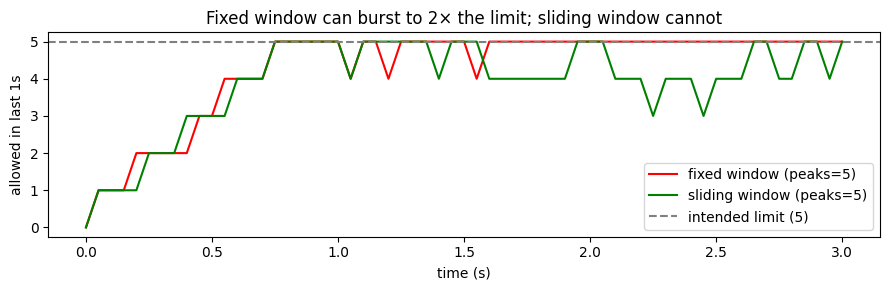

In [3]:
import matplotlib.pyplot as plt

def run(limiter, duration=3.0, rps=6):
    t0 = time.monotonic()
    allowed_at = []
    interval = 1.0 / rps
    next_t = t0
    while time.monotonic() - t0 < duration:
        now = time.monotonic()
        if now < next_t:
            time.sleep(next_t - now)
        if limiter.allow():
            allowed_at.append(time.monotonic() - t0)
        next_t += interval
    return allowed_at

fw_allowed = run(FixedWindow(limit=5, window=1.0))
sw_allowed = run(SlidingWindow(limit=5, window=1.0))

def rolling(allowed, duration=3.0, window=1.0, step=0.05):
    xs, ys = [], []
    t = 0.0
    while t <= duration:
        ys.append(sum(1 for a in allowed if t - window < a <= t))
        xs.append(t); t += step
    return xs, ys

xf, yf = rolling(fw_allowed); xs, ys = rolling(sw_allowed)

plt.figure(figsize=(9, 3))
plt.plot(xf, yf, label=f'fixed window (peaks={max(yf)})', color='red')
plt.plot(xs, ys, label=f'sliding window (peaks={max(ys)})', color='green')
plt.axhline(5, color='gray', linestyle='--', label='intended limit (5)')
plt.xlabel('time (s)'); plt.ylabel('allowed in last 1s')
plt.title('Fixed window can burst to 2× the limit; sliding window cannot')
plt.legend(); plt.tight_layout(); plt.show()

## ⚖️ Hybrid: sliding-window counter (the "Cloudflare trick")

The full log uses `O(N)` memory per key. For huge scale, a cheaper
approximation keeps **just two counters** (current and previous window)
and linearly interpolates the overlap. Almost as accurate, O(1) memory.


In [4]:
class SlidingWindowCounter:
    """O(1) approximation used at scale by Cloudflare, Kong, etc."""
    def __init__(self, limit, window):
        self.limit = limit; self.window = window
        self.curr_start = time.monotonic()
        self.curr = 0; self.prev = 0

    def allow(self):
        now = time.monotonic()
        elapsed = now - self.curr_start
        if elapsed >= self.window:
            # roll one window forward (or skip empty ones)
            rolls = int(elapsed // self.window)
            self.prev = self.curr if rolls == 1 else 0
            self.curr = 0
            self.curr_start += rolls * self.window
            elapsed = now - self.curr_start
        # weight of previous window overlapping the trailing 1s
        weight = (self.window - elapsed) / self.window
        estimate = self.prev * weight + self.curr
        if estimate < self.limit:
            self.curr += 1; return True
        return False

swc = SlidingWindowCounter(limit=5, window=1.0)
print('8 quick attempts:', [int(swc.allow()) for _ in range(8)])

8 quick attempts: [1, 1, 1, 1, 1, 0, 0, 0]


## 📊 Algorithm comparison

| Algorithm | Memory | Burst behavior | Boundary safe? | Typical use |
|---|---|---|---|---|
| Fixed window counter | O(1) | up to 2× limit at boundary | ❌ | Quick hacks |
| Sliding window log | O(N) timestamps | smooth, exact | ✅ | Small-to-medium scale |
| Sliding window counter | O(1) | ~exact (approximate) | ✅ | Cloudflare / Kong scale |
| Token bucket | O(1) | bounded burst | ✅ | AWS, Stripe |
| Leaky bucket | O(1) | no burst (paced) | ✅ | NGINX, traffic shaping |

For a **distributed** limiter (many servers, one shared counter), replace
in-memory state with **Redis** (`INCR` + TTL for fixed window, sorted sets
for a log, two counters for the hybrid). That's the topic of notebook 4.
